In [ ]:
import marimo as mo
import polars as pl
import pandas as pd
import numpy as np
import re
from scipy.stats import hypergeom
from pathlib import Path
import altair as alt

# Genome Minimizer Analysis — Cell Systems Revision

## Table of Contents
1. [Gene Enrichment](#enrichment) — hypergeometric tests for core/essential genes

In [ ]:
PROJECT_ROOT = Path("/Users/mcclainthiel/Projects/PhD/genome-minimizer-2")
DATA_DIR = PROJECT_ROOT / "data"
EVAL_DATA = PROJECT_ROOT / "evaluation" / "data"

In [ ]:
# Pangenome matrix: genes (rows) x strains (columns)
pangenome_df = pd.read_csv(DATA_DIR / "F4_complete_presence_absence.csv", index_col=0)
pangenome_df = pangenome_df.drop(index="Lineage", errors="ignore")
pangenome_genes = pangenome_df.index.tolist()
n_strains = pangenome_df.shape[1]

# Core genome: genes present in ≥95% of strains
prevalence = pangenome_df.sum(axis=1) / n_strains
core_genes = set(prevalence[prevalence >= 0.95].index.tolist())

def normalize_gene(_name: str):
    return re.sub(r"_\d+$", "", _name).lower()

mo.md(f"""
**Pangenome:** {n_strains:,} strains, {len(pangenome_genes):,} genes  
**Core genome (≥95%):** {len(core_genes):,} genes
""")

<span class="markdown prose dark:prose-invert contents"><span class="paragraph"><strong>Pangenome:</strong> 7,512 strains, 55,039 genes<br />
<strong>Core genome (≥95%):</strong> 3,091 genes</span></span>

In [ ]:
essential_df = pl.read_csv(DATA_DIR / "essential_genes.csv")
essential_genes = set(essential_df["# gene"].to_list())
mo.md(f"**Essential genes:** {len(essential_genes):,}")

<span class="markdown prose dark:prose-invert contents"><span class="paragraph"><strong>Essential genes:</strong> 358</span></span>

**Random Genomes** In order to test if the VAE was actually learning anything we compare to a random baseline. This is implemented in `evaluation/generate_random_baseline.py`. What is does it calculate the core genome (genes in >95% of the dataset) keeps all of those, then samples the remaining genes until we have as many genes as we need for comparision (generally ~3300 which is how many our best VAE produced).

In [ ]:
# Load real strains (200 random from pangenome, matching tier1_kegg.py)
_rng = np.random.default_rng(42)
_strain_cols = pangenome_df.columns.tolist()
_chosen = _rng.choice(len(_strain_cols), size=200, replace=False)
_chosen_names = [_strain_cols[_i] for _i in sorted(_chosen)]
_real_df = pangenome_df[_chosen_names]
real_gene_lists = []
for _col in _real_df.columns:
    _present = _real_df.index[_real_df[_col].astype(int) == 1].tolist()
    real_gene_lists.append(_present)

# Load model gene lists
def load_gene_lists(_variant: str):
    if _variant == "random":
        _path = EVAL_DATA / "random" / "random_gene_lists_with_essentials.npy"
    else:
        _path = EVAL_DATA / _variant / f"{_variant}_gene_lists_with_essentials.npy"
    return [list(x) for x in np.load(_path, allow_pickle=True)]

variants = ["real", "v0", "v1", "v2", "v3", "v4", "v4_opt", "random"]
gene_lists = {_v: load_gene_lists(_v) for _v in variants if _v != "real"}
gene_lists["real"] = real_gene_lists

_lines = []
for _v in variants:
    _sizes = [len(_g) for _g in gene_lists[_v]]
    _lines.append(f"- **{_v}**: n={len(gene_lists[_v])}, mean={np.mean(_sizes):.0f} genes [{min(_sizes)}–{max(_sizes)}]")
mo.md("**Gene lists loaded:**\n" + "\n".join(_lines))

<span class="markdown prose dark:prose-invert contents"><span class="paragraph"><strong>Gene lists loaded:</strong></span>
<ul>
<li><strong>real</strong>: n=200, mean=4732 genes [4149–5142]</li>
<li><strong>v0</strong>: n=100, mean=4355 genes [3875–4724]</li>
<li><strong>v1</strong>: n=100, mean=4110 genes [3664–4670]</li>
<li><strong>v2</strong>: n=100, mean=4199 genes [3676–4745]</li>
<li><strong>v3</strong>: n=100, mean=3217 genes [2709–4072]</li>
<li><strong>v4</strong>: n=100, mean=3769 genes [3508–4608]</li>
<li><strong>v4_opt</strong>: n=100, mean=4527 genes [4141–4879]</li>
<li><strong>random</strong>: n=100, mean=3268 genes [3266–3268]</li>
</ul></span>

<a id='enrichment'></a>
## 1. Gene Enrichment Analysis

We want to see if our VAE is learning so we are running an enrichment analysis to test if there are greater than the expected number of genes in our sample relative to what we would expect from random. This code uses a hypergeometric test to ask whether each gene list contains more **core genes** or **essential genes** than expected by chance. “Enriched” means the sample has a higher fraction of those target genes than the full pangenome background. The p-value tells us how likely it would be to see that many or more target genes if the sample were randomly drawn from the pangenome; small p-values suggest significant enrichment.

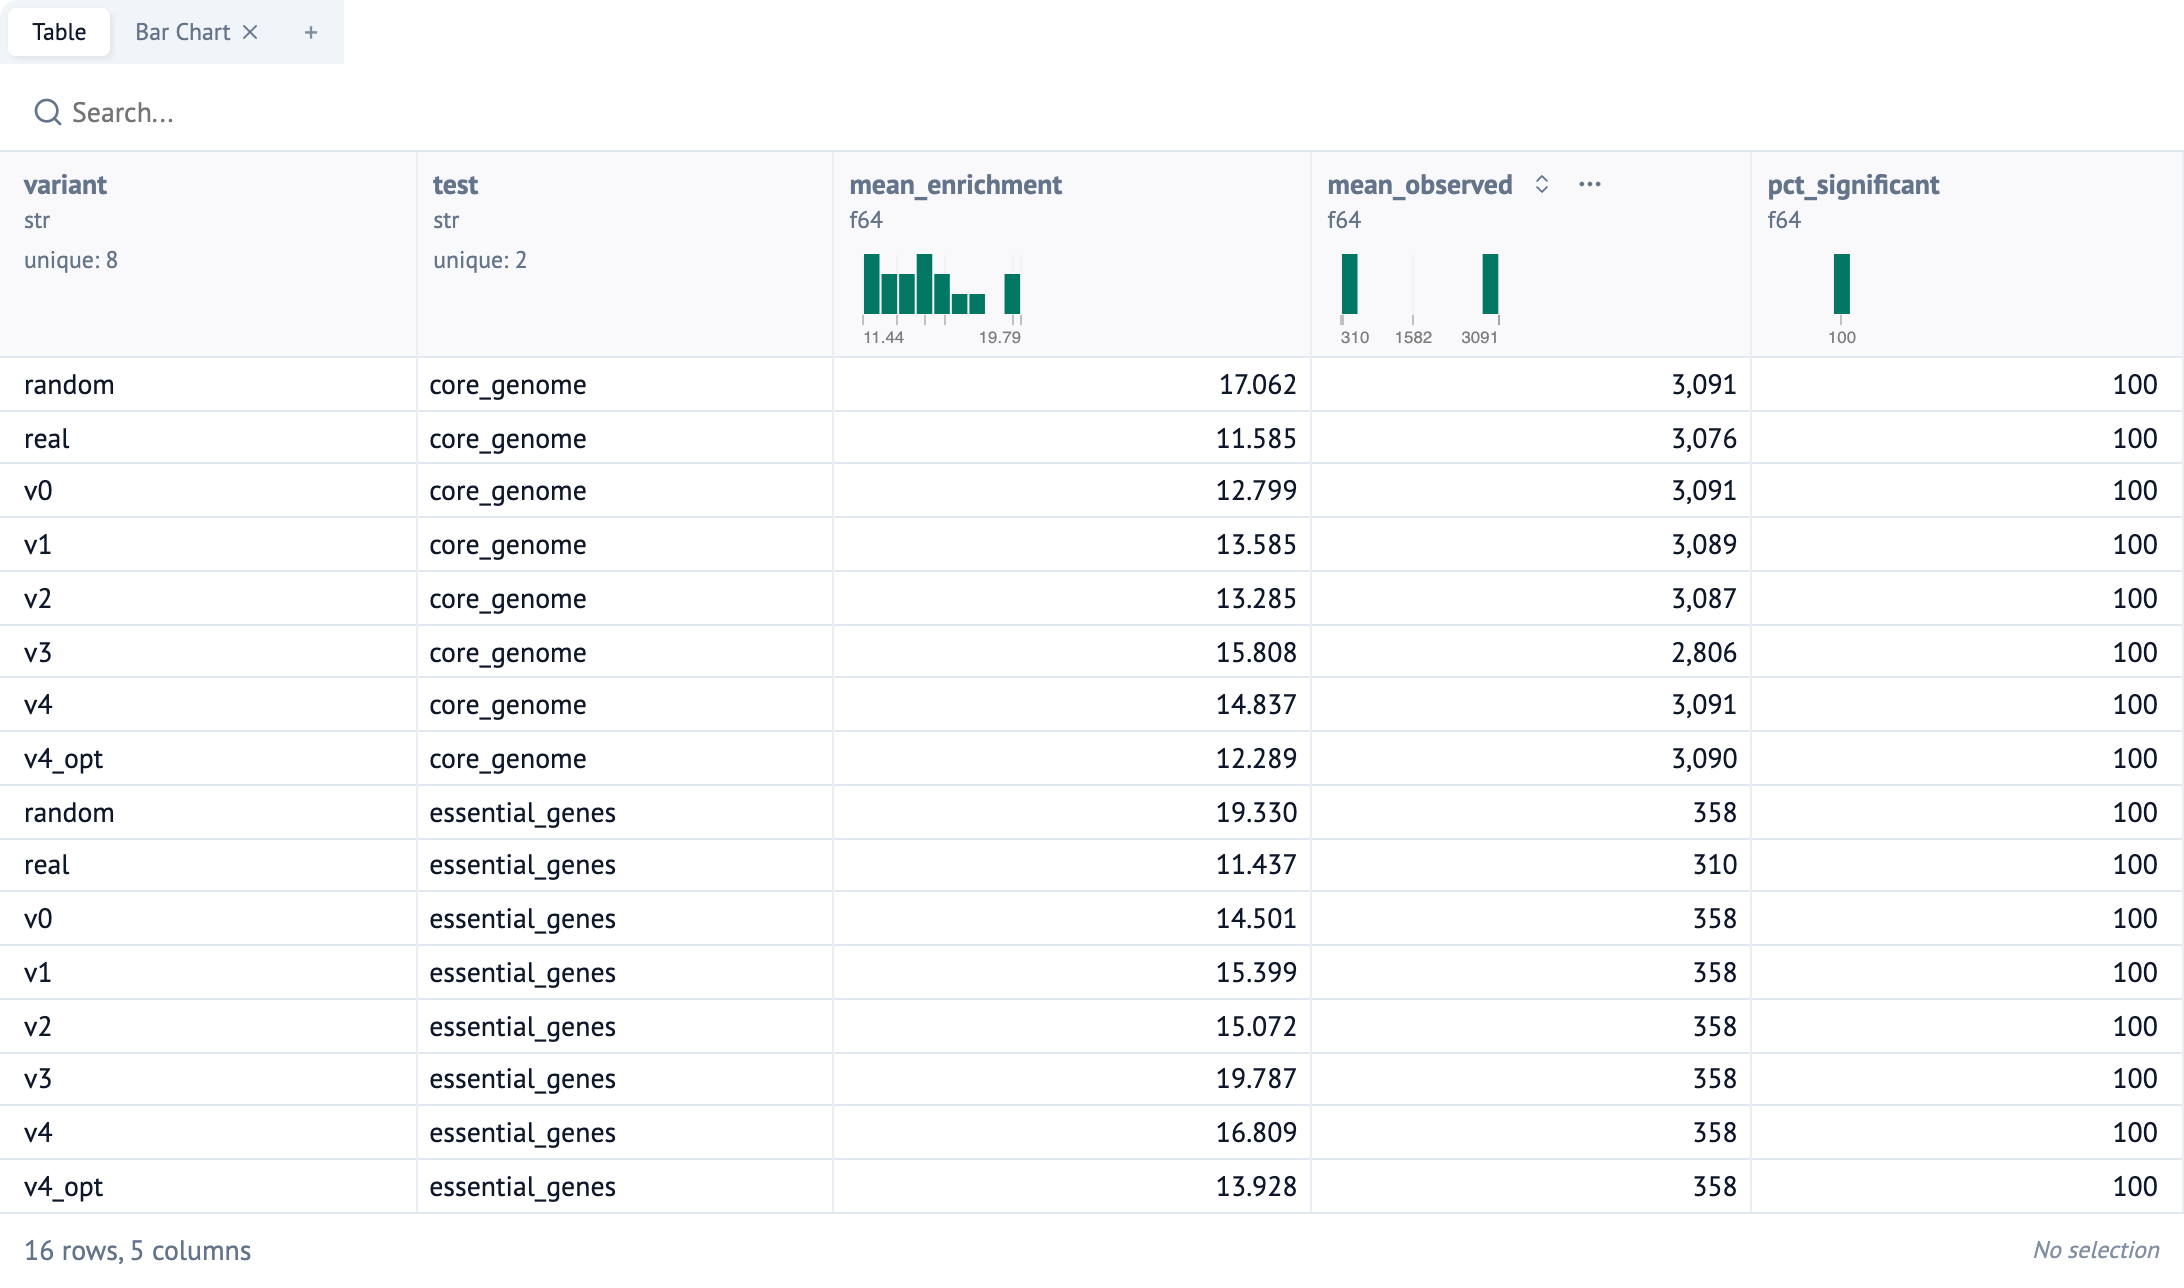

In [ ]:
def hypergeometric_enrichment(_sample_genes: set, _target_genes: set, _population_genes: set):
    _M = len(_population_genes)
    _n = len(_target_genes & _population_genes)
    _N = len(_sample_genes & _population_genes)
    _k = len(_sample_genes & _target_genes)
    _p = hypergeom.sf(_k - 1, _M, _n, _N)
    _exp = _N * _n / _M
    return {"observed": _k, "expected": round(_exp, 1), "enrichment": round(_k / _exp, 3) if _exp > 0 else 0, "p_value": _p}

_all_genes = set(pangenome_genes)
_results = []
for _variant in variants:
    for _i, _genes in enumerate(gene_lists[_variant]):
        _gene_set = set(_genes)
        _cr = hypergeometric_enrichment(_gene_set, core_genes, _all_genes)
        _results.append({"variant": _variant, "sample_id": _i, "test": "core_genome", **_cr})
        _er = hypergeometric_enrichment(_gene_set, essential_genes, _all_genes)
        _results.append({"variant": _variant, "sample_id": _i, "test": "essential_genes", **_er})

enrichment_df = pl.DataFrame(_results)

enrichment_df.group_by(["variant", "test"]).agg([
    pl.col("enrichment").mean().round(3).alias("mean_enrichment"),
    pl.col("observed").mean().round(0).alias("mean_observed"),
    (pl.col("p_value") < 0.005).mean().mul(100).round(1).alias("pct_significant"),
]).sort(["test", "variant"])